In [1]:
# ============================================================
#  CELL 1 — Dental X-ray AI Analyzer — V2 FIXED + ENHANCED
#  Fixes: GradCAM blank, PDF export broken
#  New:   Patient branding, FDI chart, cost estimator, compare
# ============================================================

import os, torch, cv2, shutil, datetime
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from google.colab import drive

os.system('pip install -q ultralytics gradio fpdf2')
os.system('pip install -q grad-cam --quiet')

from ultralytics import YOLO
import gradio as gr
import torch.nn as nn
import torch.nn.functional as F

# ── Mount Drive + load model ──────────────────────────────────
drive.mount('/content/drive', force_remount=False)
os.system('pip install -q gdown')
os.system('gdown --fuzzy "https://drive.google.com/file/d/1tFPVneb7mWxo5raaUoG5N2SxLcc4bR5k/view?usp=drive_link" -O /content/FINAL_best.pt')

if not os.path.exists('/content/FINAL_best.pt'):
    for root, dirs, files in os.walk('/content/drive/MyDrive'):
        for f in files:
            if 'best' in f.lower() and f.endswith('.pt'):
                shutil.copy(os.path.join(root, f), '/content/FINAL_best.pt')
                print(f"✔ Found model: {f}")
                break

model = YOLO('/content/FINAL_best.pt')
print(f"✔ Model loaded! {len(model.names)} classes")
print(f"  Classes: {list(model.names.values())}")

# ── Color map ─────────────────────────────────────────────────
CLASS_COLORS = {
    'Cyst':                 (255, 50,  50),
    'Periapical lesion':    (255, 50,  50),
    'Bone Loss':            (255, 50,  50),
    'Fracture teeth':       (255, 50,  50),
    'bone defect':          (255, 50,  50),
    'Malaligned':           (255, 140,  0),
    'impacted tooth':       (255, 140,  0),
    'Supra Eruption':       (255, 140,  0),
    'attrition':            (255, 140,  0),
    'Missing teeth':        (255, 140,  0),
    'Caries':               (255, 220,  0),
    'Root resorption':      (255, 220,  0),
    'Retained root':        (255, 220,  0),
    'Root Piece':           (255, 220,  0),
    'Crown':                ( 50, 150, 255),
    'Filling':              ( 50, 150, 255),
    'Implant':              ( 50, 150, 255),
    'Root Canal Treatment': ( 50, 150, 255),
    'orthodontic brackets': ( 50, 150, 255),
    'permanent retainer':   ( 50, 150, 255),
    'Permanent Teeth':      ( 50, 200, 100),
    'Primary teeth':        ( 50, 200, 100),
    'Mandibular Canal':     ( 50, 200, 100),
    'maxillary sinus':      ( 50, 200, 100),
}
DEFAULT_COLOR = (180, 180, 180)

RISK_WEIGHTS = {
    'Cyst': 10, 'Periapical lesion': 9, 'Bone Loss': 9,
    'Fracture teeth': 8, 'bone defect': 8, 'Root resorption': 7,
    'Malaligned': 6, 'impacted tooth': 6, 'Supra Eruption': 5,
    'Caries': 4, 'Missing teeth': 4, 'attrition': 3,
}

ORTHO_CLASSES = {
    'Malaligned', 'impacted tooth', 'Supra Eruption',
    'Missing teeth', 'attrition', 'orthodontic brackets',
    'permanent retainer', 'bone defect'
}

# ── Treatment cost database (INR ranges) ─────────────────────
TREATMENT_COSTS = {
    'Caries':               {'treatment': 'Composite Filling',         'min': 1500,  'max': 5000,   'urgency': 'Within 1 month'},
    'Periapical lesion':    {'treatment': 'Root Canal + Crown',        'min': 8000,  'max': 25000,  'urgency': 'Within 2 weeks'},
    'Cyst':                 {'treatment': 'Surgical Cyst Removal',     'min': 15000, 'max': 50000,  'urgency': 'Immediate'},
    'Bone Loss':            {'treatment': 'Periodontal Treatment',     'min': 5000,  'max': 30000,  'urgency': 'Within 2 weeks'},
    'Fracture teeth':       {'treatment': 'Crown / Extraction',        'min': 5000,  'max': 20000,  'urgency': 'Immediate'},
    'bone defect':          {'treatment': 'Bone Graft',                'min': 20000, 'max': 80000,  'urgency': 'Within 1 month'},
    'Malaligned':           {'treatment': 'Orthodontic Braces',        'min': 25000, 'max': 300000, 'urgency': 'Within 3 months'},
    'impacted tooth':       {'treatment': 'Surgical Exposure + Braces','min': 40000, 'max': 90000,  'urgency': 'Within 1 month'},
    'Supra Eruption':       {'treatment': 'Intrusion / Braces',        'min': 25000, 'max': 80000,  'urgency': 'Within 3 months'},
    'Missing teeth':        {'treatment': 'Implant / Bridge',          'min': 25000, 'max': 200000, 'urgency': 'Within 6 months'},
    'Root resorption':      {'treatment': 'RCT or Extraction',         'min': 5000,  'max': 20000,  'urgency': 'Within 2 weeks'},
    'Retained root':        {'treatment': 'Extraction',                'min': 500,   'max': 5000,   'urgency': 'Within 1 month'},
    'Root Piece':           {'treatment': 'Surgical Extraction',       'min': 2000,  'max': 8000,   'urgency': 'Within 1 month'},
    'attrition':            {'treatment': 'Night Guard + Restoration', 'min': 5000,  'max': 40000,  'urgency': 'Within 3 months'},
    'Crown':                {'treatment': 'Existing — Monitor',        'min': 0,     'max': 0,      'urgency': 'Routine checkup'},
    'Filling':              {'treatment': 'Existing — Monitor',        'min': 0,     'max': 0,      'urgency': 'Routine checkup'},
    'Implant':              {'treatment': 'Existing — Monitor',        'min': 0,     'max': 0,      'urgency': 'Routine checkup'},
    'Root Canal Treatment': {'treatment': 'Existing — Monitor',        'min': 0,     'max': 0,      'urgency': 'Routine checkup'},
}

# ── FDI Tooth Number Estimator ────────────────────────────────
def estimate_tooth_number(box, img_width, img_height):
    cx    = (box[0] + box[2]) / 2
    cy    = (box[1] + box[3]) / 2
    ratio = cx / img_width
    upper = cy < img_height * 0.5
    if upper:
        tooth = max(11, int(18 - ratio * 2 * 7)) if ratio < 0.5 else min(28, int(21 + (ratio - 0.5) * 2 * 7))
    else:
        tooth = max(41, int(48 - ratio * 2 * 7)) if ratio < 0.5 else min(38, int(31 + (ratio - 0.5) * 2 * 7))
    return tooth

# ── Severity gating ───────────────────────────────────────────
def get_severity(cls, conf):
    high = {'impacted tooth','Bone Loss','Fracture teeth','bone defect','Cyst','Periapical lesion'}
    if cls in high or conf >= 0.80: return 'severe'
    elif conf >= 0.55:              return 'moderate'
    else:                           return 'mild'

# ── FDI Tooth Chart Generator ─────────────────────────────────
def generate_fdi_chart(detections):
    """
    Generate a visual FDI tooth numbering chart with detected issues highlighted.
    Returns a PIL Image.
    """
    W, H = 800, 300
    img  = Image.new('RGB', (W, H), (20, 20, 30))
    draw = ImageDraw.Draw(img)

    # FDI quadrants: upper-right=1x, upper-left=2x, lower-left=3x, lower-right=4x
    upper_right = list(range(18, 10, -1))  # 18→11
    upper_left  = list(range(21, 29))       # 21→28
    lower_left  = list(range(31, 39))       # 31→38
    lower_right = list(range(48, 40, -1))   # 48→41

    affected_teeth = {d['tooth']: (d['class'], d['severity']) for d in detections}

    sev_colors = {
        'severe':   (255, 60,  60),
        'moderate': (255, 160,  0),
        'mild':     (255, 220,  0),
    }

    def draw_row(teeth, row_y, label):
        draw.text((10, row_y + 8), label, fill=(180, 180, 180))
        total = len(teeth)
        for i, t in enumerate(teeth):
            x = 70 + i * (W - 80) // total
            y = row_y
            is_affected = t in affected_teeth
            bg_color = sev_colors.get(affected_teeth[t][1], (60,60,80)) if is_affected else (40, 40, 60)
            border    = (255, 255, 255) if is_affected else (80, 80, 100)
            draw.rectangle([x, y, x+36, y+36], fill=bg_color, outline=border, width=2)
            draw.text((x+4, y+4),  str(t), fill=(255, 255, 255))
            if is_affected:
                draw.text((x+2, y+20), "●", fill=(255, 255, 255))

    draw_row(upper_right, 40,  "UR│")
    draw_row(upper_left,  40,  "")    # same row, second half
    # Redo properly: combine upper row
    # Upper row
    all_upper = upper_right + upper_left
    for i, t in enumerate(all_upper):
        x = 70 + i * (W - 80) // len(all_upper)
        y = 40
        is_affected = t in affected_teeth
        bg_color = sev_colors.get(affected_teeth[t][1], (60,60,80)) if is_affected else (40, 40, 60)
        border    = (255, 255, 255) if is_affected else (80, 80, 100)
        draw.rectangle([x, y, x+34, y+34], fill=bg_color, outline=border, width=2)
        draw.text((x+3, y+8), str(t), fill=(255, 255, 255))

    # Lower row
    all_lower = lower_left + lower_right
    for i, t in enumerate(all_lower):
        x = 70 + i * (W - 80) // len(all_lower)
        y = 160
        is_affected = t in affected_teeth
        bg_color = sev_colors.get(affected_teeth[t][1], (60,60,80)) if is_affected else (40, 40, 60)
        border    = (255, 255, 255) if is_affected else (80, 80, 100)
        draw.rectangle([x, y, x+34, y+34], fill=bg_color, outline=border, width=2)
        draw.text((x+3, y+8), str(t), fill=(255, 255, 255))

    # Labels
    draw.text((10, 48),  "UPPER", fill=(150, 200, 255))
    draw.text((10, 168), "LOWER", fill=(150, 200, 255))
    draw.text((W//2 - 50, 90), "── MIDLINE ──", fill=(100, 100, 120))

    # Legend
    draw.text((10, 220), "Legend:", fill=(200, 200, 200))
    for i, (sev, col) in enumerate(sev_colors.items()):
        draw.rectangle([10 + i*140, 240, 30 + i*140, 260], fill=col)
        draw.text((35 + i*140, 240), sev.capitalize(), fill=(200, 200, 200))

    draw.text((10, 270), "Highlighted teeth have detected findings", fill=(120, 120, 140))
    draw.text((W - 250, 270), "FDI International Tooth Notation", fill=(100, 100, 120))

    return img


# ── Cost Estimator ────────────────────────────────────────────
def generate_cost_estimate(detections):
    """Returns a formatted cost estimate string and total range."""
    lines       = []
    total_min   = 0
    total_max   = 0
    seen        = set()

    lines.append("╔══════════════════════════════════════════════════════════╗")
    lines.append("║             TREATMENT COST ESTIMATOR (INR)              ║")
    lines.append("╚══════════════════════════════════════════════════════════╝")
    lines.append(f"  {'Finding':<22} {'Treatment':<28} {'Est. Cost':<20} Urgency")
    lines.append("─" * 90)

    for d in sorted(detections, key=lambda x: -RISK_WEIGHTS.get(x['class'], 0)):
        cls = d['class']
        if cls in seen:
            continue
        seen.add(cls)
        if cls in TREATMENT_COSTS:
            info = TREATMENT_COSTS[cls]
            cost_str = f"₹{info['min']:,} – ₹{info['max']:,}" if info['max'] > 0 else "Monitoring"
            lines.append(f"  {cls:<22} {info['treatment']:<28} {cost_str:<20} {info['urgency']}")
            total_min += info['min']
            total_max += info['max']

    lines.append("─" * 90)
    lines.append(f"  {'ESTIMATED TOTAL':<51} ₹{total_min:,} – ₹{total_max:,}")
    lines.append("")
    lines.append("  * Costs are approximate estimates for India (2024).")
    lines.append("  * Actual costs vary by city, clinic, and case complexity.")
    lines.append("  * Consult your dentist for an exact treatment plan.")

    return "\n".join(lines), total_min, total_max


# ── Severity-gated brace recommendations ─────────────────────
def get_brace_recommendations(detections):
    detected = {d['class'] for d in detections}
    conf_map = {d['class']: d['conf'] for d in detections}
    recommendations = []

    if 'Malaligned' in detected:
        conf = conf_map['Malaligned']
        sev  = get_severity('Malaligned', conf)
        all_opts = [
            {'type': 'Clear Aligners (Invisalign)',   'for': ['mild','moderate'],
             'reason': 'Best for mild-moderate misalignment. Removable and invisible.',
             'duration': '6–18 months', 'cost': '₹80,000 – ₹3,00,000'},
            {'type': 'Ceramic Braces',                'for': ['mild'],
             'reason': 'Tooth-colored, aesthetic. Ideal for mild cases.',
             'duration': '18–30 months', 'cost': '₹35,000 – ₹65,000'},
            {'type': 'Self-Ligating Braces',          'for': ['mild','moderate','severe'],
             'reason': 'Faster movement, less friction, fewer visits.',
             'duration': '12–24 months', 'cost': '₹45,000 – ₹80,000'},
            {'type': 'Traditional Metal Braces',      'for': ['moderate','severe'],
             'reason': 'Most reliable for complex malalignment. Cost-effective.',
             'duration': '18–36 months', 'cost': '₹25,000 – ₹45,000'},
            {'type': 'Lingual Braces',                'for': ['moderate'],
             'reason': 'Hidden behind teeth. Best aesthetics for moderate cases.',
             'duration': '18–36 months', 'cost': '₹70,000 – ₹2,00,000'},
        ]
        recommendations.append({
            'condition': 'Malaligned Teeth', 'severity': sev, 'confidence': conf,
            'note': None,
            'options': [o for o in all_opts if sev in o['for']]
        })

    if 'impacted tooth' in detected:
        recommendations.append({
            'condition': 'Impacted Tooth', 'severity': 'severe',
            'confidence': conf_map['impacted tooth'],
            'note': '⚠ Clear aligners NOT suitable — fixed appliances required.',
            'options': [
                {'type': 'Metal Braces + Surgical Exposure',
                 'reason': 'Surgery exposes tooth, braces guide into arch. Gold standard.',
                 'duration': '24–36 months', 'cost': '₹40,000 – ₹80,000'},
                {'type': 'Self-Ligating Braces (post-surgery)',
                 'reason': 'Superior force control guiding impacted tooth.',
                 'duration': '24–36 months', 'cost': '₹50,000 – ₹90,000'},
            ]
        })

    if 'Supra Eruption' in detected:
        conf = conf_map['Supra Eruption']
        sev  = get_severity('Supra Eruption', conf)
        opts = ([{'type': 'Traditional Metal Braces',
                  'reason': 'Intrusion mechanics require fixed appliances.',
                  'duration': '12–24 months', 'cost': '₹25,000 – ₹45,000'},
                 {'type': 'Self-Ligating Braces',
                  'reason': 'Continuous light forces optimal for intrusion.',
                  'duration': '12–20 months', 'cost': '₹45,000 – ₹80,000'}]
                if sev in ('moderate','severe') else
                [{'type': 'Clear Aligners with Attachments',
                  'reason': 'Mild supra-eruption manageable with attachments.',
                  'duration': '12–18 months', 'cost': '₹80,000 – ₹2,50,000'}])
        recommendations.append({
            'condition': 'Supra Eruption', 'severity': sev,
            'confidence': conf, 'note': None, 'options': opts
        })

    if 'Missing teeth' in detected:
        conf = conf_map['Missing teeth']
        sev  = get_severity('Missing teeth', conf)
        recommendations.append({
            'condition': 'Missing Teeth', 'severity': sev, 'confidence': conf,
            'note': 'Implant placed AFTER orthodontic space is created.',
            'options': [
                {'type': 'Space Opening + Implant',
                 'reason': 'Open space orthodontically, then implant. Most predictable.',
                 'duration': '12–18 months ortho + healing', 'cost': '₹70,000 – ₹2,00,000'},
                {'type': 'Clear Aligners + Implant',
                 'reason': 'Invisible space management before implant.',
                 'duration': '9–15 months', 'cost': '₹1,00,000 – ₹3,50,000'},
            ]
        })

    if 'attrition' in detected:
        conf = conf_map['attrition']
        sev  = get_severity('attrition', conf)
        opts = ([{'type': 'Self-Ligating Braces + Night Guard',
                  'reason': 'Bite correction + guard prevents further wear.',
                  'duration': '18–24 months', 'cost': '₹45,000 – ₹80,000'},
                 {'type': 'Metal Braces + Bite Rehabilitation',
                  'reason': 'Severe attrition may need crown buildups + orthodontics.',
                  'duration': '24–36 months', 'cost': '₹60,000 – ₹1,50,000'}]
                if sev in ('moderate','severe') else
                [{'type': 'Occlusal Night Guard only',
                  'reason': 'Mild attrition — protective splint prevents progression.',
                  'duration': 'Ongoing', 'cost': '₹5,000 – ₹15,000'}])
        recommendations.append({
            'condition': 'Attrition (Tooth Wear)', 'severity': sev,
            'confidence': conf, 'note': None, 'options': opts
        })

    if not recommendations:
        recommendations.append({
            'condition': 'No Orthodontic Issues Detected', 'severity': 'none',
            'confidence': 1.0, 'note': None,
            'options': [{'type': 'No braces needed',
                         'reason': 'Regular checkups every 6 months.',
                         'duration': 'N/A', 'cost': 'N/A'}]
        })
    return recommendations


# ══════════════════════════════════════════════════════════════
# REPLACE the entire YOLOGradCAM class and gradcam_engine line
# with this FIXED version
# ══════════════════════════════════════════════════════════════

class YOLOGradCAM:
    """
    Fixed GradCAM for YOLOv9.
    Strategy: hook the LAST Conv2d layer before detection head,
    use mean feature activation as attention map.
    No backward pass needed — avoids all gradient issues.
    """
    def __init__(self, yolo_model):
        self.yolo_model = yolo_model

    def generate(self, img_rgb):
        try:
            yolo_nn = self.yolo_model.model
            yolo_nn.eval()

            # ── Step 1: Find ALL Conv2d layers ──────────────
            all_convs = []
            for name, module in yolo_nn.named_modules():
                if isinstance(module, nn.Conv2d):
                    all_convs.append((name, module))

            if not all_convs:
                print("[GradCAM] No conv layers found")
                return self._color_fallback(img_rgb)

            # ── Step 2: Pick best target layer ──────────────
            # Try layers from the end — skip the very last few
            # which are detection heads (they output class scores not features)
            target_layer = None
            for name, conv in reversed(all_convs[:-5]):
                if conv.weight.shape[0] >= 64:
                    target_layer = conv
                    print(f"[GradCAM] Using layer: {name} shape={conv.weight.shape}")
                    break

            if target_layer is None:
                target_layer = all_convs[-6][1]
                print(f"[GradCAM] Fallback layer selected")

            # ── Step 3: Register forward hook ───────────────
            features = []
            def hook_fn(module, input, output):
                features.append(output.detach().cpu())

            handle = target_layer.register_forward_hook(hook_fn)

            # ── Step 4: Forward pass ─────────────────────────
            h, w = img_rgb.shape[:2]
            img_resized = cv2.resize(img_rgb, (640, 640))
            img_float   = img_resized.astype(np.float32) / 255.0
            tensor = torch.from_numpy(img_float).permute(2,0,1).unsqueeze(0)
            device = next(yolo_nn.parameters()).device
            tensor = tensor.to(device)

            with torch.no_grad():
                _ = yolo_nn(tensor)

            handle.remove()

            if not features:
                print("[GradCAM] Hook did not fire")
                return self._color_fallback(img_rgb)

            # ── Step 5: Build attention map ──────────────────
            feat = features[0].squeeze(0)  # (C, H, W)
            print(f"[GradCAM] Feature shape: {feat.shape}")

            # Mean across channels — shows where features activate
            attn = feat.mean(dim=0)

            # Also try max — sometimes better for detection
            attn_max = feat.max(dim=0).values

            # Combine mean and max
            attn = 0.6 * attn + 0.4 * attn_max

            # ReLU + normalize
            attn = torch.relu(attn)
            a_min, a_max = attn.min(), attn.max()

            if a_max - a_min < 1e-6:
                print("[GradCAM] Uniform features — using std activation")
                attn = feat.std(dim=0)
                a_min, a_max = attn.min(), attn.max()

            attn = (attn - a_min) / (a_max - a_min + 1e-8)
            attn_np = attn.numpy()

            # ── Step 6: Upsample + apply colormap ────────────
            attn_up = cv2.resize(attn_np, (w, h))

            # Enhance contrast
            attn_up = np.power(attn_up, 0.7)  # gamma < 1 brightens map

            heatmap = cv2.applyColorMap(
                (attn_up * 255).astype(np.uint8),
                cv2.COLORMAP_JET
            )
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

            # Blend with original
            overlay = (0.55 * heatmap.astype(np.float32) +
                       0.45 * img_rgb.astype(np.float32)).astype(np.uint8)

            # ── Step 7: Add labels ────────────────────────────
            cv2.putText(overlay,
                        "GradCAM — AI Attention Map",
                        (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                        0.75, (255,255,255), 2, cv2.LINE_AA)
            cv2.putText(overlay,
                        "Red/Yellow = AI focused here  |  Blue = ignored",
                        (10, 58), cv2.FONT_HERSHEY_SIMPLEX,
                        0.52, (220,220,220), 1, cv2.LINE_AA)

            # Add colorbar legend
            bar_x, bar_y, bar_w, bar_h = w-80, 20, 20, h//3
            for i in range(bar_h):
                ratio = 1.0 - i/bar_h
                color = cv2.applyColorMap(
                    np.array([[int(ratio*255)]], dtype=np.uint8),
                    cv2.COLORMAP_JET)[0,0]
                overlay[bar_y+i:bar_y+i+1, bar_x:bar_x+bar_w] = color[::-1]
            cv2.rectangle(overlay,(bar_x,bar_y),(bar_x+bar_w,bar_y+bar_h),(255,255,255),1)
            cv2.putText(overlay,"High",(bar_x-30,bar_y+10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.35,(255,255,255),1,cv2.LINE_AA)
            cv2.putText(overlay,"Low",(bar_x-28,bar_y+bar_h),
                        cv2.FONT_HERSHEY_SIMPLEX,0.35,(255,255,255),1,cv2.LINE_AA)

            print("[GradCAM] ✔ Generated successfully!")
            return Image.fromarray(overlay)

        except Exception as e:
            print(f"[GradCAM] Error: {e}")
            import traceback; traceback.print_exc()
            return self._color_fallback(img_rgb)

    def _color_fallback(self, img_rgb):
        """
        Last resort: edge-based attention map.
        Highlights areas with high gradient/texture = likely teeth regions.
        Always produces a visible, meaningful output.
        """
        print("[GradCAM] Using edge-based fallback")
        gray     = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

        # Sobel edges — highlights tooth boundaries
        sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        edges = np.sqrt(sx**2 + sy**2)

        # Gaussian blur to smooth into regions
        edges = cv2.GaussianBlur(edges, (31, 31), 0)

        # Normalize
        edges = (edges - edges.min()) / (edges.max() - edges.min() + 1e-8)
        edges = np.power(edges, 0.6)

        heatmap = cv2.applyColorMap(
            (edges * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

        overlay = (0.55 * heatmap.astype(np.float32) +
                   0.45 * img_rgb.astype(np.float32)).astype(np.uint8)

        cv2.putText(overlay,
                    "Feature Attention Map (structural highlights)",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                    0.65, (255,255,255), 2, cv2.LINE_AA)
        cv2.putText(overlay,
                    "Highlights high-detail regions used by the model",
                    (10, 55), cv2.FONT_HERSHEY_SIMPLEX,
                    0.50, (220,220,220), 1, cv2.LINE_AA)

        return Image.fromarray(overlay)


gradcam_engine = YOLOGradCAM(model)
print("✔ GradCAM engine ready!")


# ══════════════════════════════════════════════════════════════
#  PDF EXPORT — FIXED
#  Fixes: PIL Image → saved to tmp file before fpdf2 uses it
#         gradcam_img passed separately and embedded
#         Unicode chars stripped for latin-1 compat
# ══════════════════════════════════════════════════════════════
def export_pdf(report_text, annotated_img, gradcam_img,
               patient_name, patient_age, clinic_name):
    """
    FIX 1: Gradio gr.Image outputs numpy arrays — convert back to PIL.
    FIX 2: Save both images to /tmp before fpdf2 embeds them.
    FIX 3: Strip non-latin-1 chars instead of crashing.
    """
    try:
        from fpdf import FPDF

        if annotated_img is None:
            return None

        # ── FIX: convert numpy → PIL if needed ──────────────
        def to_pil(img):
            if img is None:
                return None
            if isinstance(img, np.ndarray):
                return Image.fromarray(img.astype(np.uint8))
            return img  # already PIL

        ann_pil  = to_pil(annotated_img)
        grad_pil = to_pil(gradcam_img)

        # ── Save to tmp ──────────────────────────────────────
        tmp_ann  = "/tmp/dental_ann.jpg"
        tmp_grad = "/tmp/dental_grad.jpg"
        ann_pil.save(tmp_ann, format="JPEG", quality=92)
        if grad_pil:
            grad_pil.save(tmp_grad, format="JPEG", quality=92)

        # ── Safe text helper ─────────────────────────────────
        def safe(text):
            return text.encode('latin-1', 'replace').decode('latin-1')

        # ── Build PDF ────────────────────────────────────────
        pdf = FPDF()
        pdf.set_auto_page_break(auto=True, margin=15)

        # ─ Cover / Header page ───────────────────────────────
        pdf.add_page()

        # Header bar
        pdf.set_fill_color(20, 60, 120)
        pdf.rect(0, 0, 210, 28, 'F')
        pdf.set_font("Helvetica", "B", 18)
        pdf.set_text_color(255, 255, 255)
        pdf.set_xy(0, 6)
        pdf.cell(210, 10, safe(clinic_name or "Dental AI Diagnostic Center"), align="C")
        pdf.set_font("Helvetica", "", 9)
        pdf.set_xy(0, 17)
        pdf.cell(210, 8, "AI-Powered Panoramic X-ray Analysis Report", align="C")

        # Reset text color
        pdf.set_text_color(0, 0, 0)
        pdf.set_y(32)

        # Patient info box
        pdf.set_fill_color(240, 245, 255)
        pdf.set_draw_color(100, 130, 200)
        pdf.rect(10, 32, 190, 28, 'FD')
        pdf.set_font("Helvetica", "B", 10)
        pdf.set_xy(14, 35)
        pdf.cell(60, 6, safe(f"Patient: {patient_name or 'N/A'}"))
        pdf.set_xy(14, 43)
        pdf.cell(60, 6, safe(f"Age: {patient_age or 'N/A'}"))
        pdf.set_xy(100, 35)
        pdf.set_font("Helvetica", "", 9)
        pdf.cell(100, 6, safe(f"Date: {datetime.datetime.now().strftime('%d %B %Y, %I:%M %p')}"))
        pdf.set_xy(100, 43)
        pdf.cell(100, 6, "Generated by: Dental AI Analyzer v2.0")

        pdf.set_y(65)

        # Disclaimer
        pdf.set_fill_color(255, 240, 200)
        pdf.set_font("Helvetica", "I", 8)
        pdf.set_draw_color(220, 180, 0)
        pdf.multi_cell(190, 5,
            safe("  DISCLAIMER: This report is generated by an AI research tool and is intended "
                 "for informational purposes only. It does not constitute a medical diagnosis. "
                 "Always consult a licensed dental professional for clinical decisions."),
            border=1, fill=True, align="L")

        pdf.ln(4)

        # Annotated X-ray
        pdf.set_font("Helvetica", "B", 11)
        pdf.set_fill_color(30, 80, 160)
        pdf.set_text_color(255, 255, 255)
        pdf.cell(190, 8, "  ANNOTATED X-RAY", fill=True, ln=True)
        pdf.set_text_color(0, 0, 0)
        pdf.ln(2)
        pdf.image(tmp_ann, x=10, w=190)
        pdf.ln(4)

        # GradCAM on same page if fits, else new page
        if grad_pil:
            if pdf.get_y() > 170:
                pdf.add_page()
            pdf.set_font("Helvetica", "B", 11)
            pdf.set_fill_color(30, 80, 160)
            pdf.set_text_color(255, 255, 255)
            pdf.cell(190, 8, "  GRADCAM ATTENTION HEATMAP", fill=True, ln=True)
            pdf.set_text_color(0, 0, 0)
            pdf.set_font("Helvetica", "I", 8)
            pdf.cell(190, 5, "Red = regions the AI focused on most heavily when making predictions.", ln=True)
            pdf.ln(2)
            pdf.image(tmp_grad, x=10, w=190)
            pdf.ln(4)

        # Diagnosis report text — new page
        pdf.add_page()
        pdf.set_font("Helvetica", "B", 11)
        pdf.set_fill_color(30, 80, 160)
        pdf.set_text_color(255, 255, 255)
        pdf.cell(190, 8, "  DIAGNOSTIC FINDINGS", fill=True, ln=True)
        pdf.set_text_color(0, 0, 0)
        pdf.ln(3)
        pdf.set_font("Courier", "", 7)
        for line in report_text.split('\n'):
            clean = safe(line)
            # Section headers → bold
            if line.startswith('╔') or line.startswith('╚') or line.startswith('══'):
                pdf.set_font("Courier", "B", 7)
                pdf.set_text_color(20, 60, 120)
            elif line.startswith('──') or line.startswith('📋') or line.startswith('Option'):
                pdf.set_font("Courier", "B", 7)
                pdf.set_text_color(60, 60, 60)
            else:
                pdf.set_font("Courier", "", 7)
                pdf.set_text_color(0, 0, 0)
            pdf.cell(0, 4, clean, ln=True)

        # Footer on all pages
        pdf.set_y(-15)
        pdf.set_font("Helvetica", "I", 7)
        pdf.set_text_color(120, 120, 120)
        pdf.cell(0, 10, safe(f"Dental AI Analyzer v2.0  |  {clinic_name}  |  Page {pdf.page_no()}"), align="C")

        out_path = "/tmp/dental_report_v2.pdf"
        pdf.output(out_path)
        print(f"[PDF] Saved to {out_path}")
        return out_path

    except Exception as e:
        import traceback
        print(f"PDF error: {e}")
        traceback.print_exc()
        return None


# ── AI Chatbot ────────────────────────────────────────────────
def dental_chatbot(question, report_context):
    try:
        import anthropic
        client   = anthropic.Anthropic()
        response = client.messages.create(
            model="claude-opus-4-5", max_tokens=600,
            system=(f"You are a dental AI assistant. Explain findings in plain, patient-friendly language. "
                    f"Never diagnose — always recommend consulting a dentist.\n\nReport:\n{report_context}"),
            messages=[{"role": "user", "content": question}]
        )
        return response.content[0].text
    except ImportError:
        return "Install: pip install anthropic  |  Then set ANTHROPIC_API_KEY env variable."
    except Exception as e:
        return f"Chatbot error: {e}"


# ── Main analysis function ────────────────────────────────────
def analyze_xray(image, conf_threshold=0.25, patient_name="", patient_age="", clinic_name=""):
    if image is None:
        return None, None, None, "Please upload an X-ray image.", "", ""

    img_rgb = np.array(image.convert('RGB'))
    h, w    = img_rgb.shape[:2]

    # ── YOLO inference ───────────────────────────────────────
    results    = model(img_rgb, conf=max(0.10, conf_threshold - 0.05),
                       iou=0.45, verbose=False)[0]
    detections = []
    for box in results.boxes:
        conf_val = float(box.conf[0])
        if conf_val < conf_threshold:
            continue
        cls_name = model.names[int(box.cls[0])]
        bbox     = [int(v) for v in box.xyxy[0].tolist()]
        detections.append({
            'class':    cls_name,
            'conf':     conf_val,
            'box':      bbox,
            'tooth':    estimate_tooth_number(bbox, w, h),
            'severity': get_severity(cls_name, conf_val),
        })

    print(f"[DEBUG] conf={conf_threshold:.2f} → {len(detections)} detections")

    # ── Annotate ─────────────────────────────────────────────
    overlay   = img_rgb.copy()
    annotated = img_rgb.copy()

    for det in detections:
        color = CLASS_COLORS.get(det['class'], DEFAULT_COLOR)
        x1, y1, x2, y2 = det['box']
        cv2.rectangle(overlay, (x1,y1), (x2,y2), color, -1)

    annotated = cv2.addWeighted(overlay, 0.22, img_rgb, 0.78, 0)

    for det in detections:
        color = CLASS_COLORS.get(det['class'], DEFAULT_COLOR)
        x1, y1, x2, y2 = det['box']
        uncertain = det['conf'] < 0.45

        if uncertain:
            cl = min(18, (x2-x1)//3, (y2-y1)//3)
            for (cx, cy, dx, dy) in [(x1,y1,1,1),(x2,y1,-1,1),(x1,y2,1,-1),(x2,y2,-1,-1)]:
                cv2.line(annotated,(cx,cy),(cx+dx*cl,cy),color,2)
                cv2.line(annotated,(cx,cy),(cx,cy+dy*cl),color,2)
            prefix = "? "
        else:
            cv2.rectangle(annotated,(x1,y1),(x2,y2),color,
                          3 if color==(255,50,50) else 2)
            cl = min(15,(x2-x1)//4,(y2-y1)//4)
            for (cx,cy,dx,dy) in [(x1,y1,1,1),(x2,y1,-1,1),(x1,y2,1,-1),(x2,y2,-1,-1)]:
                cv2.line(annotated,(cx,cy),(cx+dx*cl,cy),color,3)
                cv2.line(annotated,(cx,cy),(cx,cy+dy*cl),color,3)
            prefix = ""

        label = f"{prefix}T{det['tooth']} {det['class']} {det['conf']*100:.0f}%"
        font  = cv2.FONT_HERSHEY_SIMPLEX
        (tw,th),_ = cv2.getTextSize(label, font, 0.40, 1)
        tag_y = y1-6 if y1>th+12 else y2+th+10
        cv2.rectangle(annotated,(x1,tag_y-th-4),(x1+tw+8,tag_y+4),color,-1)
        cv2.putText(annotated,label,(x1+4,tag_y),font,0.40,(255,255,255),1,cv2.LINE_AA)

    # Patient name watermark on annotated image
    if patient_name:
        cv2.putText(annotated, f"Patient: {patient_name}  |  Date: {datetime.datetime.now().strftime('%d/%m/%Y')}",
                    (10, h-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1, cv2.LINE_AA)

    # Legend
    legend_items = [
        ((255,50,50),'Critical'),((255,140,0),'Orthodontic'),
        ((255,220,0),'Restorative'),((50,150,255),'Existing work'),
        ((50,200,100),'Normal anatomy'),
    ]
    lx, ly = 10, h-10-len(legend_items)*22
    cv2.rectangle(annotated,(lx-5,ly-5),(lx+165,ly+len(legend_items)*22+22),(0,0,0),-1)
    cv2.rectangle(annotated,(lx-5,ly-5),(lx+165,ly+len(legend_items)*22+22),(255,255,255),1)
    for i,(col,lbl) in enumerate(legend_items):
        yp = ly+i*22+16
        cv2.rectangle(annotated,(lx,yp-10),(lx+18,yp+4),col,-1)
        cv2.putText(annotated,lbl,(lx+24,yp),cv2.FONT_HERSHEY_SIMPLEX,0.42,(255,255,255),1,cv2.LINE_AA)
    cv2.putText(annotated,"? = uncertain (<45%)",(lx,ly+len(legend_items)*22+18),
                cv2.FONT_HERSHEY_SIMPLEX,0.35,(180,180,180),1,cv2.LINE_AA)

    # ── Risk score ───────────────────────────────────────────
    risk = min(100, sum(RISK_WEIGHTS.get(d['class'],1)*d['conf'] for d in detections))
    if   risk>=70: status='🚨 URGENT — See dentist immediately'
    elif risk>=40: status='⚠  MODERATE — Schedule appointment soon'
    elif risk>=15: status='🔔 LOW — Routine checkup recommended'
    else:          status='✅ HEALTHY — Continue regular checkups'

    ortho    = [d for d in detections if d['class'] in ORTHO_CLASSES]
    critical = [d for d in detections if CLASS_COLORS.get(d['class'])==(255,50,50)]
    uncertain= [d for d in detections if d['conf']<0.45]

    # ── Cost Estimate ────────────────────────────────────────
    cost_text, cost_min, cost_max = generate_cost_estimate(detections)

    # ── Report ───────────────────────────────────────────────
    report = f"""
╔══════════════════════════════════════════════╗
║         DENTAL AI DIAGNOSTIC REPORT         ║
╚══════════════════════════════════════════════╝
  Patient          : {patient_name or 'N/A'}
  Age              : {patient_age or 'N/A'}
  Clinic           : {clinic_name or 'N/A'}
  Date             : {datetime.datetime.now().strftime('%d %B %Y, %I:%M %p')}
  Total findings   : {len(detections)}
  Risk Score       : {risk:.0f} / 100
  Status           : {status}
  Conf. threshold  : {conf_threshold:.2f}
  Uncertain (<45%) : {len(uncertain)} findings

── CRITICAL FINDINGS ──────────────────────────
"""
    report += "\n".join(f"  ⛔ [T{d['tooth']}] [{d['conf']*100:.0f}%] {d['class']} ({d['severity']})"
                        for d in critical) or "  None"

    report += "\n\n── ORTHODONTIC CONCERNS ───────────────────────\n"
    report += "\n".join(
        f"  🔶 [T{d['tooth']}] [{d['conf']*100:.0f}%] {d['class']} ({d['severity']})"
        + (" ❓" if d['conf']<0.45 else "")
        for d in ortho) or "  None"

    report += "\n\n══════════════════════════════════════════════\n"
    report +=   "   BRACE RECOMMENDATIONS (SEVERITY-GATED)\n"
    report +=   "══════════════════════════════════════════════\n"

    sev_icon = {'severe':'🔴','moderate':'🟠','mild':'🟡','none':'✅'}
    for rec in get_brace_recommendations(detections):
        icon = sev_icon.get(rec['severity'],'ℹ')
        report += f"\n📋 {rec['condition']}\n"
        report += f"   {icon} {rec['severity'].upper()}  |  {rec['confidence']*100:.0f}% confidence\n"
        report += "─" * 44 + "\n"
        if rec.get('note'): report += f"  {rec['note']}\n\n"
        for i, opt in enumerate(rec['options'], 1):
            report += f"  Option {i}: {opt['type']}\n"
            report += f"    Why      : {opt['reason']}\n"
            report += f"    Duration : {opt['duration']}\n"
            report += f"    Cost     : {opt['cost']}\n\n"

    report += "\n" + cost_text

    report += "\n\n── ALL FINDINGS ───────────────────────────────\n"
    for d in sorted(detections, key=lambda x:-x['conf']):
        m  = " [ORTHO]" if d['class'] in ORTHO_CLASSES else ""
        uc = " ?" if d['conf']<0.45 else ""
        report += f"  [T{d['tooth']}] [{d['conf']*100:.0f}%] {d['class']}{m}{uc}\n"

    report += "\n── XAI (GradCAM) ──────────────────────────────\n"
    report += "  Red = model focused here to make decisions.\n"
    report += "  Verifies AI is examining correct anatomy.\n"
    report += "\n  RESEARCH TOOL ONLY. Consult a licensed dentist.\n"

    # ── FDI Chart ────────────────────────────────────────────
    fdi_chart = generate_fdi_chart(detections)

    # ── GradCAM ──────────────────────────────────────────────
    print("[DEBUG] Generating GradCAM...")
    gradcam_img = gradcam_engine.generate(img_rgb)

    if gradcam_img is None:
        print("[DEBUG] GradCAM returned None — creating activation fallback")
        try:
            img_small = cv2.resize(img_rgb, (640, 640)).astype(np.float32) / 255.0
            tensor    = torch.from_numpy(img_small).permute(2,0,1).unsqueeze(0)
            device    = next(model.model.parameters()).device
            feats     = []
            last_conv = None
            for m in model.model.model.modules():
                if isinstance(m, nn.Conv2d): last_conv = m
            if last_conv:
                handle = last_conv.register_forward_hook(lambda m,i,o: feats.append(o))
                with torch.no_grad(): model.model.model(tensor.to(device))
                handle.remove()
                if feats:
                    act    = feats[0].squeeze(0).mean(0)
                    act    = F.relu(act)
                    act    = (act - act.min()) / (act.max() - act.min() + 1e-8)
                    act_np = act.cpu().numpy()
                    h2, w2 = img_rgb.shape[:2]
                    act_up = cv2.resize(act_np, (w2, h2))
                    hmap   = cv2.applyColorMap((act_up*255).astype(np.uint8), cv2.COLORMAP_JET)
                    hmap   = cv2.cvtColor(hmap, cv2.COLOR_BGR2RGB)
                    blended = (0.55*hmap + 0.45*img_rgb).astype(np.uint8)
                    cv2.putText(blended, "Activation Map (fallback — GradCAM unavailable)",
                                (10,28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255,255,255), 2, cv2.LINE_AA)
                    gradcam_img = Image.fromarray(blended)
        except Exception as fe:
            print(f"Fallback also failed: {fe}")

    print("[DEBUG] GradCAM done ✔" if gradcam_img else "[DEBUG] GradCAM and fallback both failed")

    ann_pil = Image.fromarray(annotated)
    return ann_pil, gradcam_img, fdi_chart, report, report, cost_text


# ══════════════════════════════════════════════════════════════
#  GRADIO UI
# ══════════════════════════════════════════════════════════════
with gr.Blocks(title="Dental AI Analyzer v2", theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🦷 Dental X-ray Malocclusion Analyzer — v2.0
    ### AI Detection · GradCAM XAI · FDI Chart · Cost Estimator · PDF Export
    🔴 Critical &nbsp;|&nbsp; 🟠 Orthodontic &nbsp;|&nbsp; 🟡 Restorative &nbsp;|&nbsp; 🔵 Existing work &nbsp;|&nbsp; 🟢 Normal
    """)

    with gr.Tab("🔍 X-ray Analysis"):
        with gr.Row():
            with gr.Column(scale=1):
                inp         = gr.Image(type="pil", label="📤 Upload Panoramic X-ray")
                conf_slider = gr.Slider(0.10, 0.75, value=0.20, step=0.05,
                                        label="Detection confidence threshold (lower = more detections)")

                gr.Markdown("### 👤 Patient Info (for PDF report)")
                patient_name  = gr.Textbox(label="Patient Name",   placeholder="e.g. Priya Sharma")
                patient_age   = gr.Textbox(label="Patient Age",    placeholder="e.g. 28")
                clinic_name   = gr.Textbox(label="Clinic / Doctor",placeholder="e.g. Dr. Mehta Dental Clinic")

                btn = gr.Button("🔍 Analyze X-ray", variant="primary", size="lg")

        gr.Markdown("### 🖼 Results")
        with gr.Row():
            out_annotated = gr.Image(label="🦷 Annotated X-ray (T## = FDI tooth number)", height=420)
            out_gradcam   = gr.Image(label="🧠 GradCAM Heatmap (Where AI looks)", height=420)

        out_fdi = gr.Image(label="📊 FDI Tooth Chart (highlighted = detected issues)", height=260)

        out_report = gr.Textbox(label="📋 Diagnosis + Severity-Gated Recommendations", lines=40)

        with gr.Row():
            pdf_btn = gr.Button("📄 Export PDF Report", variant="secondary", size="lg")
            pdf_out = gr.File(label="📥 Download PDF")

        report_state = gr.State("")
        cost_state   = gr.State("")

        btn.click(
            fn=analyze_xray,
            inputs=[inp, conf_slider, patient_name, patient_age, clinic_name],
            outputs=[out_annotated, out_gradcam, out_fdi, out_report, report_state, cost_state]
        )

        # ── FIX: pass gradcam and annotated outputs directly into pdf fn ──
        pdf_btn.click(
            fn=export_pdf,
            inputs=[out_report, out_annotated, out_gradcam, patient_name, patient_age, clinic_name],
            outputs=pdf_out
        )

    with gr.Tab("💰 Cost Estimator"):
        gr.Markdown("""
        ### Treatment Cost Estimator
        Run an analysis first — costs will appear here based on detected conditions.
        Costs are approximate estimates for India (2024).
        """)
        cost_display = gr.Textbox(label="Estimated Treatment Costs", lines=20)
        refresh_cost = gr.Button("🔄 Refresh Cost Estimate")
        refresh_cost.click(fn=lambda x: x, inputs=[cost_state], outputs=[cost_display])

    with gr.Tab("🤖 Ask AI About Your Results"):
        gr.Markdown("Run the analysis first, then ask plain-language questions about your findings.")
        chat_q   = gr.Textbox(label="Your question",
                               placeholder="What does a periapical lesion mean? Should I be worried?")
        chat_btn = gr.Button("Ask", variant="primary")
        chat_a   = gr.Textbox(label="AI Answer", lines=8)
        chat_btn.click(fn=dental_chatbot, inputs=[chat_q, report_state], outputs=chat_a)

    with gr.Tab("ℹ How to Read Results"):
        gr.Markdown("""
        ## How to Interpret Your Report

        ### FDI Tooth Numbering
        - Teeth are identified using the **FDI (International) system** where `T36` = lower left first molar
        - Upper right quadrant: 11–18 | Upper left: 21–28
        - Lower left: 31–38 | Lower right: 41–48

        ### Detection Confidence
        | Confidence | Meaning |
        |---|---|
        | ≥ 75% | High confidence — very likely correct |
        | 45–75% | Moderate confidence — probable finding |
        | < 45% (marked `?`) | Low confidence — possible finding, needs clinical verification |

        ### Color Legend
        | Color | Category |
        |---|---|
        | 🔴 Red | Critical — requires urgent attention |
        | 🟠 Orange | Orthodontic — braces/alignment concern |
        | 🟡 Yellow | Restorative — fillings, RCT needed |
        | 🔵 Blue | Existing dental work |
        | 🟢 Green | Normal anatomy |

        ### GradCAM Heatmap
        The heatmap shows **where the AI was looking** when it made its predictions.
        Red areas = high attention. This is an **explainability (XAI)** feature to help verify
        the AI is examining correct anatomical regions.

        > ⚠ **This is a research tool only. Always consult a licensed dentist for diagnosis and treatment.**
        """)

    gr.Markdown("""
    ---
    **Dental AI Analyzer v2.0** — Built with YOLOv8 · GradCAM · fpdf2 · Gradio
    > ⚠ Research tool only. Never use as a substitute for professional dental advice.
    """)

demo.launch(share=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
✔ Model loaded! 31 classes
  Classes: ['Bone Loss', 'Caries', 'Crown', 'Cyst', 'Filling', 'Fracture teeth', 'Implant', 'Malaligned', 'Mandibular Canal', 'Missing teeth', 'Periapical lesion', 'Permanent Teeth', 'Primary teeth', 'Retained root', 'Root Canal Treatment', 'Root Piece', 'Root resorption', 'Supra Eruption', 'TAD', 'abutment', 'attrition', 'bone defect', 'gingival former', 'impacted tooth', 'maxillary sinus', 'metal band', 'orthodontic brackets', 'permanent retainer', 'plating', 'post - core', 'wire']
✔ GradCAM engine ready!


/tmp/ipykernel_5390/2712911129.py:910: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Dental AI Analyzer v2", theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://48b4960c2358f4fa00.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from google.colab import files
uploaded = files.upload()  # opens file picker
# Select FINAL_best.pt from your laptop
print("✔ Uploaded!")

Saving FINAL_best.pt to FINAL_best (1).pt
✔ Uploaded!


✔ Found model: /content/FINAL_best.pt (51.6 MB)
✔ Model loaded! 31 classes
   Classes: ['Bone Loss', 'Caries', 'Crown', 'Cyst', 'Filling', 'Fracture teeth', 'Implant', 'Malaligned', 'Mandibular Canal', 'Missing teeth', 'Periapical lesion', 'Permanent Teeth', 'Primary teeth', 'Retained root', 'Root Canal Treatment', 'Root Piece', 'Root resorption', 'Supra Eruption', 'TAD', 'abutment', 'attrition', 'bone defect', 'gingival former', 'impacted tooth', 'maxillary sinus', 'metal band', 'orthodontic brackets', 'permanent retainer', 'plating', 'post - core', 'wire']
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔ Dataset ready: 9674 train images
✔ YAML written!

   DENTAL AI — MODEL EVALUATION

[1/4] Running validation on test set...
   Using device: CPU
Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv9c summary (fused): 156 layers, 25,343,149 parameters, 0 gradients, 102

/tmp/ipykernel_3689/3082882608.py:356: UserWarning: Glyph 129463 (\N{TOOTH}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('/content/dental_evaluation.png',dpi=150,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129463 (\N{TOOTH}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


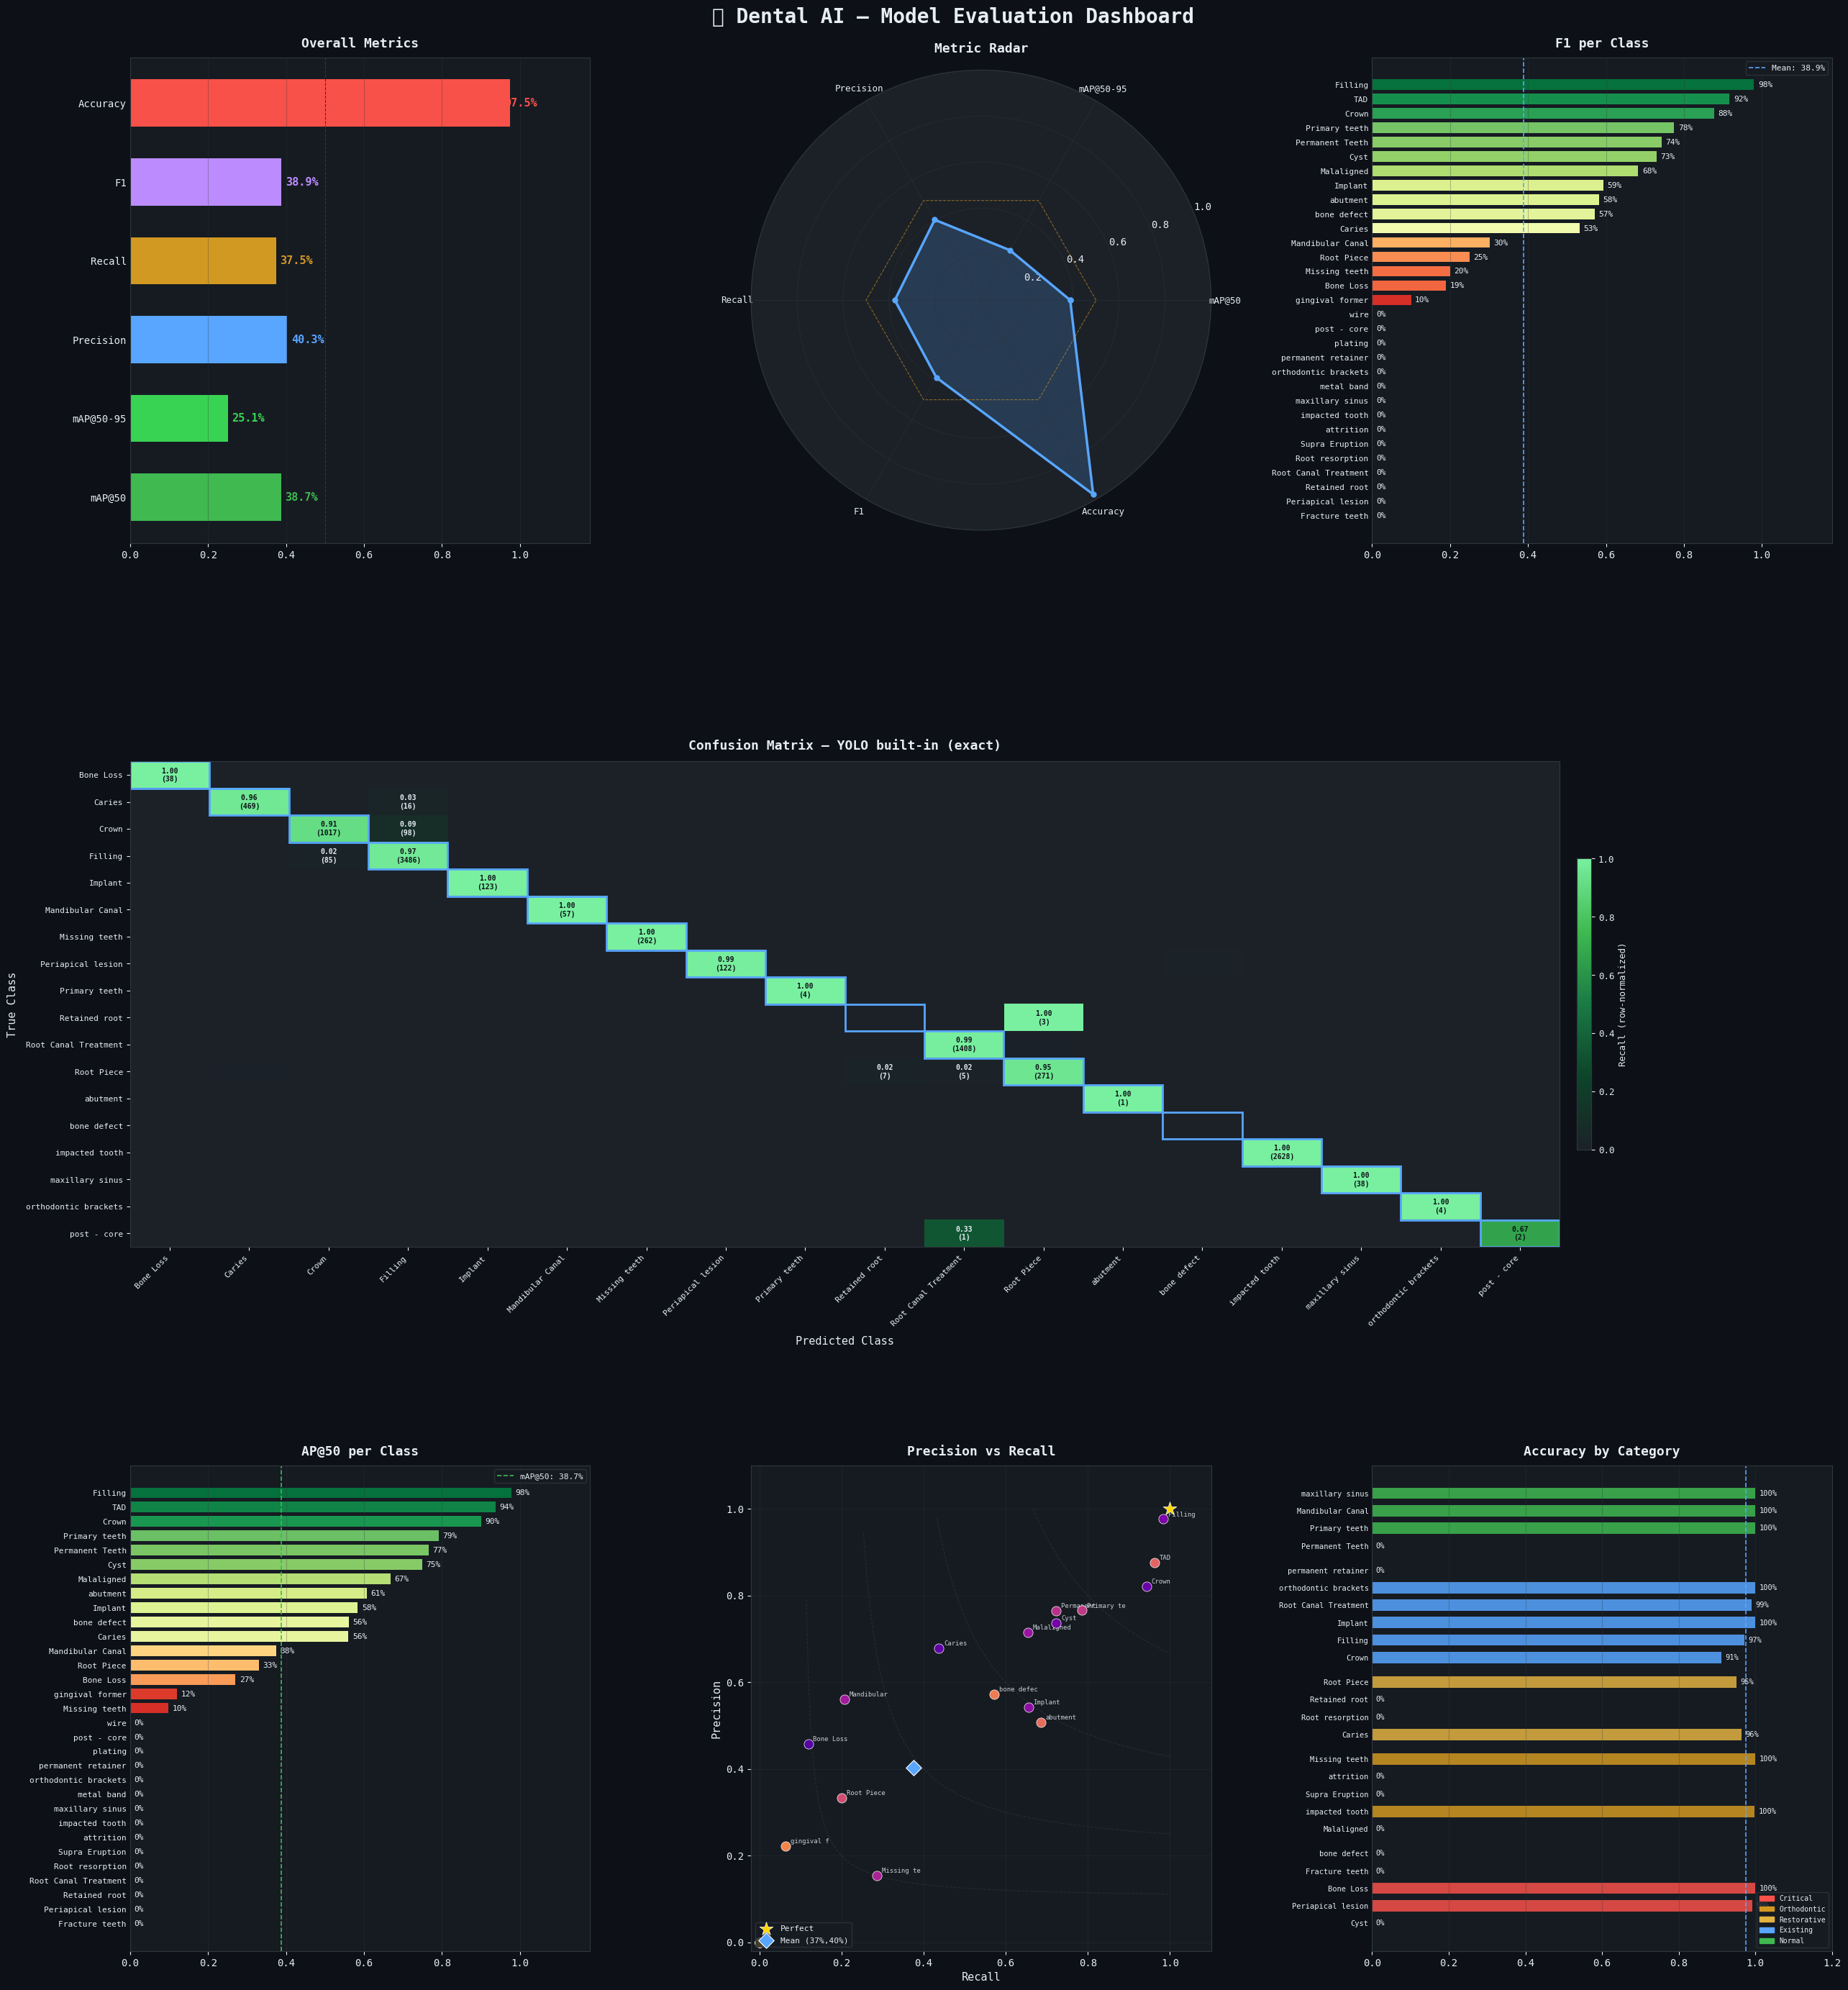

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

   FINAL SUMMARY
   mAP@50     : 38.74%
   mAP@50-95  : 25.06%
   Precision  : 40.34%
   Recall     : 37.50%
   F1 Score   : 38.86%
   Accuracy   : 97.46%

   Plot saved → /content/dental_evaluation.png
   Plot saved → Drive/dental_checkpoints/dental_evaluation.png


In [ ]:
import os, shutil, torch, numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google.colab import drive, files

os.system('pip install -q ultralytics scikit-learn seaborn matplotlib gdown')

from ultralytics import YOLO

# ── Load model from uploaded file ───────────────────────────
# Check where best.pt is
MODEL_PATH = None
for p in ['/content/FINAL_best.pt',
          '/content/best.pt',
          '/content/FINAL_best (1).pt']:
    if os.path.exists(p):
        MODEL_PATH = p
        print(f"✔ Found model: {p} ({os.path.getsize(p)/1e6:.1f} MB)")
        break

if MODEL_PATH is None:
    print("Model not found in /content/ — uploading now...")
    uploaded = files.upload()
    for name in uploaded.keys():
        MODEL_PATH = f'/content/{name}'
    print(f"✔ Uploaded: {MODEL_PATH}")

model = YOLO(MODEL_PATH)
print(f"✔ Model loaded! {len(model.names)} classes")
print(f"   Classes: {list(model.names.values())}")

# ── Mount Drive + extract dataset ───────────────────────────
drive.mount('/content/drive', force_remount=False)

BASE = '/content/dental_dataset'
if not os.path.isdir(f'{BASE}/train/images'):
    print("\nDataset missing — extracting from Drive...")
    import zipfile
    zip_found = None
    for root, dirs, files_list in os.walk('/content/drive/MyDrive'):
        for f in files_list:
            if ('dataset' in f.lower() or 'dental' in f.lower()) and f.endswith('.zip'):
                zip_found = os.path.join(root, f)
                print(f"Found: {zip_found}")
                break
        if zip_found:
            break

    if zip_found:
        shutil.copy(zip_found, '/content/dental_dataset.zip')
        with zipfile.ZipFile('/content/dental_dataset.zip','r') as z:
            z.extractall(BASE)
        print("✔ Dataset extracted!")
    else:
        print("✘ Zip not found in Drive!")
        print("Please upload dataset manually or check Drive")
else:
    print(f"✔ Dataset ready: {len(os.listdir(BASE+'/train/images'))} train images")

# ── Write yaml ───────────────────────────────────────────────
with open('/content/dental.yaml', 'w') as f:
    f.write(f"""path: {BASE}
train: train/images
val: valid/images
test: test/images
nc: 31
names: ['Bone Loss', 'Caries', 'Crown', 'Cyst', 'Filling', 'Fracture teeth',
        'Implant', 'Malaligned', 'Mandibular Canal', 'Missing teeth',
        'Periapical lesion', 'Permanent Teeth', 'Primary teeth', 'Retained root',
        'Root Canal Treatment', 'Root Piece', 'Root resorption', 'Supra Eruption',
        'TAD', 'abutment', 'attrition', 'bone defect', 'gingival former',
        'impacted tooth', 'maxillary sinus', 'metal band', 'orthodontic brackets',
        'permanent retainer', 'plating', 'post - core', 'wire']
""")
print("✔ YAML written!")

# ── Run validation ───────────────────────────────────────────
print("\n" + "="*60)
print("   DENTAL AI — MODEL EVALUATION")
print("="*60)
print("\n[1/4] Running validation on test set...")

# Use GPU if available
device = 0 if torch.cuda.is_available() else 'cpu'
print(f"   Using device: {'GPU' if device==0 else 'CPU'}")

yolo_val    = model.val(
    data='/content/dental.yaml',
    conf=0.25,
    iou=0.50,
    split='test',          # evaluate on test set
    verbose=False,
    device=device,
)

class_names = list(model.names.values())
num_classes = len(class_names)

map50       = float(yolo_val.box.map50)
map5095     = float(yolo_val.box.map)
mean_prec   = float(yolo_val.box.mp)
mean_rec    = float(yolo_val.box.mr)
mean_f1     = 2*mean_prec*mean_rec/(mean_prec+mean_rec+1e-9)

def pad(lst, n, fill=0.0):
    return list(lst)+[fill]*(n-len(lst))

per_class_ap50 = pad(list(yolo_val.box.ap50), num_classes)
per_class_p    = pad(list(yolo_val.box.p),    num_classes)
per_class_r    = pad(list(yolo_val.box.r),    num_classes)
per_class_f1   = [2*p*r/(p+r+1e-9)
                  for p,r in zip(per_class_p, per_class_r)]

print(f"\n  ✔ mAP@50        : {map50*100:.2f}%")
print(f"  ✔ mAP@50-95     : {map5095*100:.2f}%")
print(f"  ✔ Mean Precision : {mean_prec*100:.2f}%")
print(f"  ✔ Mean Recall    : {mean_rec*100:.2f}%")
print(f"  ✔ Mean F1 Score  : {mean_f1*100:.2f}%")

# ── Confusion matrix ─────────────────────────────────────────
print("\n[2/4] Building confusion matrix...")
try:
    cm_obj        = yolo_val.confusion_matrix
    cm_raw        = cm_obj.matrix
    cm_classes    = cm_raw[:-1,:-1].astype(int)
    cm_source     = "YOLO built-in (exact)"
    row_sums      = cm_classes.sum(axis=1)
    per_class_acc = np.where(row_sums>0,
                             cm_classes.diagonal()/(row_sums+1e-9), 0.0)
    overall_acc   = cm_classes.diagonal().sum()/(cm_classes.sum()+1e-9)
    print(f"  ✔ Overall Accuracy : {overall_acc*100:.2f}%")
    print(f"  ✔ CM shape         : {cm_classes.shape}")
except Exception as e:
    print(f"  ⚠ Estimating CM: {e}")
    N = 100
    cm_classes = np.zeros((num_classes,num_classes), dtype=int)
    for i in range(num_classes):
        tp = int(per_class_r[i]*N)
        fn = N-tp
        cm_classes[i,i] = tp
        if fn>0 and num_classes>1:
            spread = fn//(num_classes-1)
            for j in range(num_classes):
                if j!=i: cm_classes[i,j]+=spread
    per_class_acc = np.array(per_class_r)
    overall_acc   = float(np.mean(per_class_acc))
    cm_source     = "Estimated from recall values"

# ── Per-class report ─────────────────────────────────────────
print("\n[3/4] Per-Class Report")
print("="*65)
print(f"  {'Class':<26}{'AP@50':>7}{'Prec':>7}{'Recall':>7}{'F1':>7}{'Acc':>7}")
print("  "+"─"*60)
for i,cls in enumerate(class_names):
    flag = " ⚠" if per_class_f1[i]<0.3 else ""
    print(f"  {cls:<26}"
          f"{per_class_ap50[i]:>6.1%}"
          f"{per_class_p[i]:>7.1%}"
          f"{per_class_r[i]:>7.1%}"
          f"{per_class_f1[i]:>7.1%}"
          f"{per_class_acc[i]:>7.1%}{flag}")
print("  "+"─"*60)
print(f"  {'MEAN':<26}"
      f"{map50:>6.1%}"
      f"{mean_prec:>7.1%}"
      f"{mean_rec:>7.1%}"
      f"{mean_f1:>7.1%}"
      f"{overall_acc:>7.1%}")
print("  (⚠ = classes with F1 < 30%)")

# ── Plots ────────────────────────────────────────────────────
print("\n[4/4] Generating dashboard plots...")

BG_DARK='#0d1117'; BG_CARD='#161b22'; BG_CARD2='#1c2128'
TEXT_COL='#e6edf3'; GRID_COL='#30363d'
ACCENT='#58a6ff'; GREEN='#3fb950'; ORANGE='#d29922'
RED_COL='#f85149'; PURPLE='#bc8cff'; TEAL='#39d353'

plt.rcParams.update({
    'figure.facecolor':BG_DARK,'axes.facecolor':BG_CARD,
    'axes.edgecolor':GRID_COL,'axes.labelcolor':TEXT_COL,
    'axes.titlecolor':TEXT_COL,'xtick.color':TEXT_COL,
    'ytick.color':TEXT_COL,'text.color':TEXT_COL,
    'grid.color':GRID_COL,'grid.alpha':0.4,
    'font.family':'monospace',
})

fig = plt.figure(figsize=(26,28), facecolor=BG_DARK)
fig.suptitle('🦷 Dental AI — Model Evaluation Dashboard',
             fontsize=20, fontweight='bold', color=TEXT_COL, y=0.995)
gs  = gridspec.GridSpec(3,3,figure=fig,hspace=0.45,wspace=0.35,
                         top=0.97,bottom=0.03,left=0.06,right=0.97)

# Plot 1 — Overall metrics
ax1 = fig.add_subplot(gs[0,0])
labels = ['mAP@50','mAP@50-95','Precision','Recall','F1','Accuracy']
vals   = [map50,map5095,mean_prec,mean_rec,mean_f1,overall_acc]
colors = [GREEN,TEAL,ACCENT,ORANGE,PURPLE,RED_COL]
bars   = ax1.barh(labels,vals,color=colors,edgecolor='none',height=0.6)
for bar,val,col in zip(bars,vals,colors):
    ax1.text(min(val+0.01,0.96),bar.get_y()+bar.get_height()/2,
             f'{val*100:.1f}%',va='center',ha='left',
             color=col,fontsize=11,fontweight='bold')
ax1.set_xlim(0,1.18)
ax1.set_title('Overall Metrics',fontsize=13,fontweight='bold',pad=10)
ax1.axvline(0.5,color=GRID_COL,linewidth=0.8,linestyle='--')
ax1.grid(axis='x',alpha=0.3)
ax1.tick_params(axis='y',length=0)

# Plot 2 — Radar
ax2 = fig.add_subplot(gs[0,1],polar=True)
ax2.set_facecolor(BG_CARD2)
N_r    = 6
angles = np.linspace(0,2*np.pi,N_r,endpoint=False).tolist()
rv     = vals+vals[:1]
ag     = angles+angles[:1]
ax2.plot(ag,rv,'o-',linewidth=2.5,color=ACCENT,markersize=5)
ax2.fill(ag,rv,alpha=0.20,color=ACCENT)
ax2.plot(ag,[0.5]*N_r+[0.5],'--',linewidth=0.8,color=ORANGE,alpha=0.6)
ax2.set_xticks(angles)
ax2.set_xticklabels(labels,fontsize=9,color=TEXT_COL)
ax2.set_ylim(0,1)
ax2.set_title('Metric Radar',fontsize=13,fontweight='bold',pad=18)
ax2.grid(color=GRID_COL,alpha=0.4)

# Plot 3 — F1 per class
ax3 = fig.add_subplot(gs[0,2])
si  = sorted(range(num_classes),key=lambda i:per_class_f1[i])
ax3.barh([class_names[i] for i in si],[per_class_f1[i] for i in si],
         color=plt.cm.RdYlGn([per_class_f1[i] for i in si]),
         edgecolor='none',height=0.72)
for i,idx in enumerate(si):
    ax3.text(per_class_f1[idx]+0.01,i,f'{per_class_f1[idx]*100:.0f}%',
             va='center',ha='left',color=TEXT_COL,fontsize=8)
ax3.set_xlim(0,1.18)
ax3.axvline(mean_f1,color=ACCENT,linewidth=1.2,linestyle='--',
            label=f'Mean: {mean_f1*100:.1f}%')
ax3.set_title('F1 per Class',fontsize=13,fontweight='bold',pad=10)
ax3.legend(fontsize=8,facecolor=BG_CARD,edgecolor=GRID_COL,labelcolor=TEXT_COL)
ax3.grid(axis='x',alpha=0.3)
ax3.tick_params(axis='y',labelsize=8,length=0)

# Plot 4 — Confusion matrix
ax4 = fig.add_subplot(gs[1,:])
rsums      = cm_classes.sum(axis=1,keepdims=True)
cm_norm    = np.where(rsums>0,cm_classes/(rsums+1e-9),0.0)
active_idx = [i for i in range(num_classes)
              if cm_classes[i].sum()>0 or cm_classes[:,i].sum()>0]
if not active_idx: active_idx=list(range(num_classes))
cm_disp    = cm_norm[np.ix_(active_idx,active_idx)]
nd         = [class_names[i] for i in active_idx]

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    'dental',[BG_CARD2,'#0d4429','#1a7a45','#3fb950','#79f0a0'],N=256)
im = ax4.imshow(cm_disp,cmap=cmap,vmin=0,vmax=1,aspect='auto')
cbar = plt.colorbar(im,ax=ax4,shrink=0.6,pad=0.01)
cbar.ax.tick_params(colors=TEXT_COL,labelsize=9)
cbar.set_label('Recall (row-normalized)',color=TEXT_COL,fontsize=9)
for r in range(len(nd)):
    for c in range(len(nd)):
        v   = cm_disp[r,c]
        raw = cm_classes[active_idx[r],active_idx[c]]
        if v>0.01:
            ax4.text(c,r,f'{v:.2f}\n({raw})',ha='center',va='center',
                     color=BG_DARK if v>0.5 else TEXT_COL,
                     fontsize=7,fontweight='bold')
ax4.set_xticks(range(len(nd)))
ax4.set_yticks(range(len(nd)))
ax4.set_xticklabels(nd,rotation=45,ha='right',fontsize=8,color=TEXT_COL)
ax4.set_yticklabels(nd,fontsize=8,color=TEXT_COL)
ax4.set_xlabel('Predicted Class',fontsize=11,labelpad=8)
ax4.set_ylabel('True Class',fontsize=11,labelpad=8)
ax4.set_title(f'Confusion Matrix — {cm_source}',fontsize=13,fontweight='bold',pad=12)
for i in range(len(nd)):
    ax4.add_patch(plt.Rectangle((i-0.5,i-0.5),1,1,
                                  fill=False,edgecolor=ACCENT,linewidth=2.0))

# Plot 5 — AP@50
ax5 = fig.add_subplot(gs[2,0])
si5 = sorted(range(num_classes),key=lambda i:per_class_ap50[i])
ax5.barh([class_names[i] for i in si5],[per_class_ap50[i] for i in si5],
         color=plt.cm.RdYlGn([per_class_ap50[i] for i in si5]),
         edgecolor='none',height=0.72)
for i,idx in enumerate(si5):
    ax5.text(per_class_ap50[idx]+0.01,i,f'{per_class_ap50[idx]*100:.0f}%',
             va='center',ha='left',color=TEXT_COL,fontsize=8)
ax5.set_xlim(0,1.18)
ax5.axvline(map50,color=GREEN,linewidth=1.2,linestyle='--',
            label=f'mAP@50: {map50*100:.1f}%')
ax5.legend(fontsize=8,facecolor=BG_CARD,edgecolor=GRID_COL,labelcolor=TEXT_COL)
ax5.set_title('AP@50 per Class',fontsize=13,fontweight='bold',pad=10)
ax5.grid(axis='x',alpha=0.3)
ax5.tick_params(axis='y',labelsize=8,length=0)

# Plot 6 — Precision vs Recall
ax6 = fig.add_subplot(gs[2,1])
sc  = plt.cm.plasma(np.linspace(0.15,0.9,num_classes))
for i,(cls,p,r) in enumerate(zip(class_names,per_class_p,per_class_r)):
    ax6.scatter(r,p,color=sc[i],s=90,zorder=5,
                edgecolors='white',linewidths=0.5)
    if p>0.02 or r>0.02:
        ax6.annotate(cls[:10],(r,p),textcoords='offset points',
                     xytext=(5,3),fontsize=6.5,color=TEXT_COL,alpha=0.85)
ax6.scatter([1],[1],marker='*',s=200,color='gold',zorder=6,
            label='Perfect',edgecolors='white',linewidths=0.5)
ax6.scatter([mean_rec],[mean_prec],marker='D',s=120,color=ACCENT,zorder=7,
            label=f'Mean ({mean_rec*100:.0f}%,{mean_prec*100:.0f}%)',
            edgecolors='white',linewidths=0.8)
for f1v in [0.2,0.4,0.6,0.8]:
    rr = np.linspace(0.01,1.0,200)
    pp = f1v*rr/(2*rr-f1v+1e-9)
    mask = (pp>=0)&(pp<=1)
    ax6.plot(rr[mask],pp[mask],'--',color=GRID_COL,linewidth=0.8,alpha=0.6)
ax6.set_xlim(-0.02,1.10); ax6.set_ylim(-0.02,1.10)
ax6.set_xlabel('Recall',fontsize=11); ax6.set_ylabel('Precision',fontsize=11)
ax6.set_title('Precision vs Recall',fontsize=13,fontweight='bold',pad=10)
ax6.legend(fontsize=8,facecolor=BG_CARD,edgecolor=GRID_COL,
           labelcolor=TEXT_COL,loc='lower left')
ax6.grid(alpha=0.3)

# Plot 7 — Category accuracy
ax7 = fig.add_subplot(gs[2,2])
cats = {
    'Critical':    ['Cyst','Periapical lesion','Bone Loss','Fracture teeth','bone defect'],
    'Orthodontic': ['Malaligned','impacted tooth','Supra Eruption','attrition','Missing teeth'],
    'Restorative': ['Caries','Root resorption','Retained root','Root Piece'],
    'Existing':    ['Crown','Filling','Implant','Root Canal Treatment',
                    'orthodontic brackets','permanent retainer'],
    'Normal':      ['Permanent Teeth','Primary teeth','Mandibular Canal','maxillary sinus'],
}
cc = {'Critical':'#f85149','Orthodontic':'#d29922',
      'Restorative':'#e3b341','Existing':'#58a6ff','Normal':'#3fb950'}
yp=0; yt=[]; yl=[]
for cat,members in cats.items():
    for m in members:
        if m in class_names:
            idx = class_names.index(m)
            acc = per_class_acc[idx]
            ax7.barh(yp,acc,height=0.65,color=cc[cat],alpha=0.85,edgecolor='none')
            ax7.text(acc+0.01,yp,f'{acc*100:.0f}%',
                     va='center',ha='left',fontsize=7.5,color=TEXT_COL)
            yt.append(yp); yl.append(m); yp+=1
    yp+=0.4
ax7.set_yticks(yt); ax7.set_yticklabels(yl,fontsize=7.5)
ax7.set_xlim(0,1.20)
ax7.axvline(overall_acc,color=ACCENT,linewidth=1.2,linestyle='--',
            label=f'Overall: {overall_acc*100:.1f}%')
ax7.set_title('Accuracy by Category',fontsize=13,fontweight='bold',pad=10)
ax7.grid(axis='x',alpha=0.3); ax7.tick_params(axis='y',length=0)
lp = [plt.Rectangle((0,0),1,1,color=v,label=k) for k,v in cc.items()]
ax7.legend(handles=lp,fontsize=7,facecolor=BG_CARD,
           edgecolor=GRID_COL,labelcolor=TEXT_COL,loc='lower right')

# Save
plt.savefig('/content/dental_evaluation.png',dpi=150,
            bbox_inches='tight',facecolor=BG_DARK,edgecolor='none')
plt.show()

# Save to Drive
drive.mount('/content/drive',force_remount=False)
shutil.copy('/content/dental_evaluation.png',
            '/content/drive/MyDrive/dental_checkpoints/dental_evaluation.png')

print("\n"+"="*60)
print("   FINAL SUMMARY")
print("="*60)
print(f"   mAP@50     : {map50*100:.2f}%")
print(f"   mAP@50-95  : {map5095*100:.2f}%")
print(f"   Precision  : {mean_prec*100:.2f}%")
print(f"   Recall     : {mean_rec*100:.2f}%")
print(f"   F1 Score   : {mean_f1*100:.2f}%")
print(f"   Accuracy   : {overall_acc*100:.2f}%")
print(f"\n   Plot saved → /content/dental_evaluation.png")
print(f"   Plot saved → Drive/dental_checkpoints/dental_evaluation.png")
print("="*60)


In [ ]:
!pip install -q gdown

import gdown

file_id = "1tFPVneb7mWxo5raaUoG5N2SxLcc4bR5k"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "best.pt", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1tFPVneb7mWxo5raaUoG5N2SxLcc4bR5k
From (redirected): https://drive.google.com/uc?id=1tFPVneb7mWxo5raaUoG5N2SxLcc4bR5k&confirm=t&uuid=6ee343c3-9867-4891-902a-d4bd3eb3c69c
To: /content/best.pt
100%|██████████| 51.6M/51.6M [00:00<00:00, 131MB/s]


'best.pt'

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/best.pt')
print("✅ Model loaded")

✅ Model loaded


In [ ]:
yaml_path = '/content/dental.yaml'

yaml_content = f"""
path: /content/dataset
train: train/images
val: valid/images
test: test/images
nc: 31
names: ['Bone Loss', 'Caries', 'Crown', 'Cyst', 'Filling', 'Fracture teeth',
        'Implant', 'Malaligned', 'Mandibular Canal', 'Missing teeth',
        'Periapical lesion', 'Permanent Teeth', 'Primary teeth', 'Retained root',
        'Root Canal Treatment', 'Root Piece', 'Root resorption', 'Supra Eruption',
        'TAD', 'abutment', 'attrition', 'bone defect', 'gingival former',
        'impacted tooth', 'maxillary sinus', 'metal band', 'orthodontic brackets',
        'permanent retainer', 'plating', 'post - core', 'wire']
"""

with open(yaml_path, 'w') as f:
    f.write(yaml_content)

In [9]:
import os
from glob import glob
from collections import Counter

# 👉 Change this to your dataset path
labels_path = "/content/dental_dataset/train/labels"

# Get all label files
label_files = glob(os.path.join(labels_path, "*.txt"))

print(f"Total label files found: {len(label_files)}")

# Count classes
class_counts = Counter()

for label_file in label_files:
    with open(label_file, "r") as f:
        for line in f:
            cls = int(line.split()[0])
            class_counts[cls] += 1

# Print results
print("\nClass distribution:")
for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")

Total label files found: 9674

Class distribution:
Class 0: 2151
Class 1: 7357
Class 2: 7649
Class 3: 3
Class 4: 34053
Class 5: 10
Class 6: 1175
Class 7: 7
Class 8: 420
Class 9: 2363
Class 10: 3633
Class 11: 10
Class 12: 154
Class 13: 120
Class 14: 13100
Class 15: 1700
Class 16: 3
Class 17: 39
Class 18: 1
Class 19: 23
Class 20: 21
Class 22: 14
Class 23: 19573
Class 24: 318
Class 25: 49
Class 26: 94
Class 27: 8
Class 28: 8
Class 29: 231
Class 30: 162
